In [113]:
from pathlib import Path # tool for working w file and filepaths
import pandas as pd
import numpy as np

RAW_DATA_DIR = Path("../data/raw")

In [12]:
orders = pd.read_csv(RAW_DATA_DIR / "olist_orders_dataset.csv")

In [13]:
orders.head() # shows first 5 rows of table

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [14]:
orders.shape # checks how large the table is (rows, cols)

(99441, 8)

In [15]:
orders.info() # shows each column name and how many non-missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [16]:
orders["order_status"].value_counts() # see different order statsu

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [17]:
orders["order_status"].value_counts(normalize=True) * 100 # proportions to percentage

order_status
delivered      97.020344
shipped         1.113223
canceled        0.628513
unavailable     0.612423
invoiced        0.315765
processing      0.302692
created         0.005028
approved        0.002011
Name: proportion, dtype: float64

In [18]:
orders.isna().sum() # how many missing values in each col

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [19]:
orders["order_id"].nunique() # check is order_id unique
# one row per order

99441

In [20]:
orders["customer_id"].nunique()

99441

In [21]:
customers = pd.read_csv(RAW_DATA_DIR / "olist_customers_dataset.csv")

In [ ]:
customers["customer_unique_id"].nunique() #96096
# 99441 - 96096 = 3345 extra orders


96096

In [ ]:
# shows 10 customers with most orders
# value_counts() sort highest to lowest by default
customers["customer_unique_id"].value_counts().head(10)

customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455    17
3e43e6105506432c953e165fb2acf44c     9
1b6c7548a2a1f9037c1fd3ddfed95f33     7
ca77025e7201e3b30c44b472ff346268     7
6469f99c1f9dfae7733b25662e7f1782     7
63cfc61cee11cbe306bff5857d00bfe4     6
47c1a3033b8b77b3ab6e109eb4d5fdf3     6
12f5d6e1cbf93dafd9dcc19095df0b3d     6
de34b16117594161a6a89c50b289d35a     6
dc813062e0fc23409cd255f7f53c7074     6
Name: count, dtype: int64

In [26]:
# how many customers ordered more than once
order_counts = customers["customer_unique_id"].value_counts()

(order_counts > 1).sum()

np.int64(2997)

In [27]:
repeated_customers_percent = 2997 / 96096 * 100
print(repeated_customers_percent)

3.1187562437562435


In [28]:
# Inspect order items table
order_items = pd.read_csv(
    RAW_DATA_DIR / "olist_order_items_dataset.csv"
)

In [29]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [ ]:
order_items.shape
# more items than num of orders, so orders contain multiple items

(112650, 7)

In [31]:
order_items["order_id"].nunique()

98666

In [32]:
order_items["order_id"].value_counts().head(10)

order_id
8272b63d03f5f79c56e9e4120aec44ef    21
1b15974a0141d54e36626dca3fdc731a    20
ab14fdcfbe524636d65ee38360e22ce8    20
9ef13efd6949e4573a18964dd1bbe7f5    15
428a2f660dc84138d969ccd69a0ab6d5    15
9bdc4d4c71aa1de4606060929dee888c    14
73c8ab38f07dc94389065f7eba4f297a    14
37ee401157a3a0b28c9c6d0ed8c3b24b    13
2c2a19b5703863c908512d135aa6accc    12
c05d6a79e55da72ca780ce90364abed9    12
Name: count, dtype: int64

In [ ]:
items_per_order = order_items["order_id"].value_counts()

(items_per_order == 1).sum()
# 88863 orders have one item
# so 98666 - 88863 = number of rows with multiple items

np.int64(88863)

In [34]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [35]:
# have freight costs exceed product price?
(order_items["freight_value"] > order_items["price"]).sum()

np.int64(4124)

In [37]:
round((order_items["freight_value"] > order_items["price"]).mean() * 100, 2)

np.float64(3.66)

In [38]:
order_items[["price", "freight_value"]].describe()

,price,freight_value
count,112650.000000,112650.000000
mean,120.653739,19.990320
std,183.633928,15.806405
min,0.850000,0.000000
25%,39.900000,13.080000
50%,74.990000,16.260000
75%,134.900000,21.150000
max,6735.000000,409.680000


In [39]:
# whats the typical freight cost relative to item price?
order_items["freight_ratio"] = (
    order_items["freight_value"] / order_items["price"]
)

In [40]:
order_items[["price", "freight_value", "freight_ratio"]].head()

,price,freight_value,freight_ratio
0,58.90,13.29,0.225637
1,239.90,19.93,0.083076
2,199.00,17.87,0.089799
3,12.99,12.79,0.984604
4,199.90,18.14,0.090745


In [ ]:
order_items["freight_ratio"].describe()
# Median = 0.231
# For a typical item, freight is about 23.1% of the product price.
# Mean = 0.321
# The average is about 32.1%, higher than the median because some rows have extremely large ratios.
# 75th percentile = 0.393
# About 75% of item rows have freight below roughly 39.3% of product price.
# Maximum = 26.24
# One item had freight equal to about 2,624% of its price. That likely happens because the product itself was extremely cheap,
# not necessarily because freight was hundreds of dollars.

count    112650.000000
mean          0.320864
std           0.349894
min           0.000000
25%           0.134034
50%           0.231356
75%           0.393036
max          26.235294
Name: freight_ratio, dtype: float64

In [ ]:
order_items.sort_values("freight_ratio", ascending=False)[
    ["order_id", "price", "freight_value", "freight_ratio"]
].head(10)
# A high freight ratio can come from either expensive shipping, a very cheap product, or both

,order_id,price,freight_value,freight_ratio
87081,c5bdd8ef3c0ec420232e668302179113,0.85,22.30,26.235294
27652,3ee6513ae7ea23bdfab5b9ab60bffcb5,0.85,18.23,21.447059
48625,6e864b3f0ec71031117ad4cf46b7f2a1,0.85,18.23,21.447059
110535,fb265b2dc558a56445dfc48f8224e201,9.90,121.22,12.244444
94495,d642656598ae928a250620315d19e87e,4.99,37.04,7.422846
57304,8272b63d03f5f79c56e9e4120aec44ef,1.20,7.89,6.575000
57309,8272b63d03f5f79c56e9e4120aec44ef,1.20,7.89,6.575000
57308,8272b63d03f5f79c56e9e4120aec44ef,1.20,7.89,6.575000
57307,8272b63d03f5f79c56e9e4120aec44ef,1.20,7.89,6.575000
57306,8272b63d03f5f79c56e9e4120aec44ef,1.20,7.89,6.575000


In [44]:
# inspect products table
products = pd.read_csv(RAW_DATA_DIR / "olist_products_dataset.csv")
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [45]:
products.shape

(32951, 9)

In [46]:
products["product_id"].nunique()

32951

In [47]:
products.isna().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [48]:
products["product_category_name"].value_counts().head(10)

product_category_name
cama_mesa_banho           3029
esporte_lazer             2867
moveis_decoracao          2657
beleza_saude              2444
utilidades_domesticas     2335
automotivo                1900
informatica_acessorios    1639
brinquedos                1411
relogios_presentes        1329
telefonia                 1134
Name: count, dtype: int64

In [49]:
# inspect translations table
category_translation = pd.read_csv(
    RAW_DATA_DIR / "product_category_name_translation.csv"
)

category_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [50]:
category_translation.shape

(71, 2)

In [51]:
# inspect sellers table
sellers = pd.read_csv(RAW_DATA_DIR / "olist_sellers_dataset.csv")
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [52]:
sellers.shape

(3095, 4)

In [53]:
sellers["seller_id"].nunique()

3095

In [54]:
# inspect reviews table
reviews = pd.read_csv(
    RAW_DATA_DIR / "olist_order_reviews_dataset.csv"
)

reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [ ]:
# Do late deliveries receive worse review scores?

In [55]:
reviews.shape

(99224, 7)

In [56]:
# does each order only have 1 review
reviews["order_id"].nunique()

98673

In [ ]:
reviews["order_id"].value_counts().gt(1).sum()
# 547 orders have more than 1 review

np.int64(547)

In [58]:
reviews["review_score"].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

In [ ]:
# later check: does late orders correlate w 1 stars

In [59]:
reviews["review_score"].value_counts(normalize=True).sort_index() * 100

review_score
1    11.513344
2     3.175643
3     8.242965
4    19.291704
5    57.776344
Name: proportion, dtype: float64

In [61]:
negative_review_rate = (reviews["review_score"] <= 2).mean() * 100
round(negative_review_rate, 2)

np.float64(14.69)

In [62]:
# inspect payments table
payments = pd.read_csv(
    RAW_DATA_DIR / "olist_order_payments_dataset.csv"
)

payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [63]:
payments.shape

(103886, 5)

In [64]:
payments["order_id"].nunique()

99440

In [ ]:
# how many orders have more than one payment row
payments["order_id"].value_counts().gt(1).sum()
# payments is a one-to-many table relative to orders.
# that means joining it directly to orders could duplicate
# those 2,961 orders. later we need to aggregate payments
# to one row per order.

np.int64(2961)

In [66]:
payments["payment_type"].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [67]:
payments.loc[
    payments["payment_type"] == "credit_card",
    "payment_installments"
].value_counts().sort_index()

payment_installments
0         2
1     25455
2     12413
3     10461
4      7098
5      5239
6      3920
7      1626
8      4268
9       644
10     5328
11       23
12      133
13       16
14       15
15       74
16        5
17        8
18       27
20       17
21        3
22        1
23        1
24       18
Name: count, dtype: int64

In [68]:
# inspect geolocation table
geolocation = pd.read_csv(
    RAW_DATA_DIR / "olist_geolocation_dataset.csv"
)

geolocation.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [69]:
geolocation.shape

(1000163, 5)

In [70]:
geolocation["geolocation_zip_code_prefix"].nunique()

19015

In [71]:
table_summary = pd.DataFrame({
    "table": [
        "orders",
        "customers",
        "order_items",
        "products",
        "category_translation",
        "sellers",
        "reviews",
        "payments",
        "geolocation"
    ],
    "rows": [
        len(orders),
        len(customers),
        len(order_items),
        len(products),
        len(category_translation),
        len(sellers),
        len(reviews),
        len(payments),
        len(geolocation)
    ]
})

table_summary

,table,rows
0,orders,99441
1,customers,99441
2,order_items,112650
3,products,32951
4,category_translation,71
5,sellers,3095
6,reviews,99224
7,payments,103886
8,geolocation,1000163


orders: one row per order
customers: one row per order-level customer ID
order_items: one row per item in an order
products: one row per product
sellers: one row per seller
reviews: one row per review, with some orders repeated
payments: one row per payment record, with some orders repeated
geolocation: many rows per ZIP prefix

In [72]:
orders[
    [
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
].dtypes

order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

In [74]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

orders[date_columns] = orders[date_columns].apply(pd.to_datetime)
orders[date_columns].dtypes

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [75]:
orders["delivery_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.days

In [76]:
orders["delivery_days"].describe()

count    96476.000000
mean        12.094086
std          9.551746
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64

In [77]:
orders["days_vs_estimate"] = (
    orders["order_delivered_customer_date"]
    - orders["order_estimated_delivery_date"]
).dt.days

In [78]:
orders["days_vs_estimate"].describe()

count    96476.000000
mean       -11.876881
std         10.183854
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: days_vs_estimate, dtype: float64

In [82]:
orders["is_late"] = orders["days_vs_estimate"] > 0

In [83]:
delivered_orders = orders[
    orders["order_delivered_customer_date"].notna()
]

delivered_orders["is_late"].mean() * 100

np.float64(6.773705377503212)

In [84]:
# compare review scores from late vs on time orders
# first, we need a review table with one score per order
# use average school when order has multiple reviews
review_by_order = (
    reviews.groupby("order_id", as_index=False)["review_score"]
    .mean()
)

review_by_order.head()

,order_id,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,5.0
1,00018f77f2f0320c557190d7a144bdd3,4.0
2,000229ec398224ef6ca0657da4fc703e,5.0
3,00024acbcdf0a6daa1e931b038114c75,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0


In [85]:
# connect delivery data to review data
orders_with_reviews = delivered_orders.merge(
    review_by_order,
    on="order_id",
    how="left"
)

In [86]:
orders_with_reviews[
    ["order_id", "is_late", "review_score"]
].head()

,order_id,is_late,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,False,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,False,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,False,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,False,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,False,5.0


In [87]:
# do late deliveries give worse reviews
orders_with_reviews.groupby("is_late")["review_score"].mean()

is_late
False    4.290450
True     2.271937
Name: review_score, dtype: float64

### Initial finding

Delivered orders that arrived on time or early had an average review score of 4.29, while late orders averaged only 2.27. This suggests that late delivery is strongly associated with lower customer satisfaction.

In [88]:
# are late orders also much more likely to receive worse reviews?
orders_with_reviews["is_negative_review"] = (
    orders_with_reviews["review_score"] <= 2
)

In [89]:
orders_with_reviews.groupby("is_late")["is_negative_review"].mean() * 100

is_late
False     9.184910
True     60.887529
Name: is_negative_review, dtype: float64

### Negative-review finding

About 60.9% of late orders received a 1- or 2-star review, compared with only 9.2% of orders delivered on time or early. Late delivery is therefore strongly associated with customer dissatisfaction.

which factors are associated with late delivery?
# investigate: 
# seller handling time (how long it took from order approval until the package was handed to the carrier.)
# freight cost
# product category
# seller/customer location
# shipping distance

In [90]:
# days from order approval to when the seller handed the package to the carrier
orders["handling_days"] = (
    orders["order_delivered_carrier_date"]
    - orders["order_approved_at"]
).dt.days

orders["handling_days"].describe()

count    97644.000000
mean         2.301749
std          3.560283
min       -172.000000
25%          0.000000
50%          1.000000
75%          3.000000
max        125.000000
Name: handling_days, dtype: float64

In [91]:
(orders["handling_days"] < 0).sum()

np.int64(1359)

In [93]:
# when handling days is negative replace with missing value

orders.loc[
    orders["handling_days"] < 0,
    "handling_days"
] = pd.NA
(orders["handling_days"] < 0).sum()

np.int64(0)

In [94]:
orders.groupby("is_late")["handling_days"].mean()

is_late
False    2.161894
True     5.078495
Name: handling_days, dtype: float64

Delays may start before shipping even begins. Sellers took longer to prepare and hand off orders that eventually arrived late.

Late orders had an average seller handling time of 5.08 days, compared with 2.16 days for orders delivered on time or early. This suggests that delays often begin before the package is handed to the carrier.

In [95]:
orders["handling_group"] = pd.cut(
    orders["handling_days"],
    bins=[-0.1, 1, 3, 7, float("inf")],
    labels=[
        "0–1 days",
        "2–3 days",
        "4–7 days",
        "8+ days"
    ]
)

In [96]:
orders.groupby("handling_group", observed=True)["is_late"].mean() * 100

handling_group
0–1 days     4.595703
2–3 days     6.232930
4–7 days     9.055194
8+ days     24.308733
Name: is_late, dtype: float64

### Seller handling-time finding

Late-delivery rates increased as seller handling time grew. Orders handed to the carrier within 0–1 day had a 4.6% late-delivery rate, while orders requiring 8 or more days had a 24.3% late-delivery rate. This suggests that unusually slow seller preparation is an important operational risk indicator.

In [98]:
# what about from carrier to arrival date
orders["transit_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_delivered_carrier_date"]
).dt.days
orders["transit_days"].describe()

count    96475.000000
mean         8.878310
std          8.746088
min        -17.000000
25%          4.000000
50%          7.000000
75%         12.000000
max        205.000000
Name: transit_days, dtype: float64

In [99]:
(orders["transit_days"] < 0).sum()

np.int64(23)

In [100]:
orders.loc[
    orders["transit_days"] < 0,
    "transit_days"
] = pd.NA
(orders["transit_days"] < 0).sum()

np.int64(0)

In [101]:
orders.groupby("is_late")["transit_days"].mean()

is_late
False     7.536511
True     27.388124
Name: transit_days, dtype: float64

Compared with the earlier handling result:

Seller handling difference: about 3 extra days
Carrier transit difference: about 20 extra days

That suggests the bigger delay is usually happening after the package is handed to the carrier, not only while the seller is preparing it.

### Transit-time finding

Late orders spent an average of 27.39 days in carrier transit, compared with 7.54 days for orders delivered on time or early. The transit-time gap was much larger than the seller handling-time gap, suggesting that carrier transit is the larger source of delay among late orders.

In [102]:
# maybe longer carrier time bc of distance
geo_by_zip = (
    geolocation.groupby("geolocation_zip_code_prefix", as_index=False)
    [["geolocation_lat", "geolocation_lng"]]
    .mean()
)

geo_by_zip.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
0,1001,-23.550190,-46.634024
1,1002,-23.548146,-46.634979
2,1003,-23.548994,-46.635731
3,1004,-23.549799,-46.634757
4,1005,-23.549456,-46.636733


In [ ]:
customers_with_geo = customers.merge(
    geo_by_zip,
    left_on="customer_zip_code_prefix",
    right_on="geolocation_zip_code_prefix",
    how="left"
)

customers_with_geo.head()
# each customer row now has: their ZIP prefix, average latitude, average longitude

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,14409.0,-20.498489,-47.396929
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,9790.0,-23.727992,-46.542848
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,1151.0,-23.531642,-46.656289
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,8775.0,-23.499702,-46.185233
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,13056.0,-22.975100,-47.142925


In [104]:
# do the same w sellers
sellers_with_geo = sellers.merge(
    geo_by_zip,
    left_on="seller_zip_code_prefix",
    right_on="geolocation_zip_code_prefix",
    how="left"
)

sellers_with_geo.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP,13023.0,-22.893848,-47.061337
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP,13844.0,-22.383437,-46.947927
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ,20031.0,-22.909572,-43.177703
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP,4195.0,-23.657242,-46.612831
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP,12914.0,-22.964803,-46.534419


In [105]:
# order -> seller -> customer -> late status
order_routes = order_items[
    ["order_id", "seller_id"]
].merge(
    orders[["order_id", "customer_id", "is_late"]],
    on="order_id",
    how="left"
)

order_routes.head()

,order_id,seller_id,customer_id,is_late
0,00010242fe8c5a6d1ba2dd792cb16214,48436dade18ac8b2bce089ec2a041202,3ce436f183e68e07877b285a838db11a,False
1,00018f77f2f0320c557190d7a144bdd3,dd7ddc04e1b6c2c614352b383efe2d36,f6dd3ec061db4e3987629fe6b26e5cce,False
2,000229ec398224ef6ca0657da4fc703e,5b51032eddd242adc84c38acab88f23d,6489ae5e4333f3693df5ad4372dab6d3,False
3,00024acbcdf0a6daa1e931b038114c75,9d7a1d34a5052409006425275ba1c2b4,d4eb9395c8c0431ee92fce09860c5a06,False
4,00042b26cf59d7ce69dfabb4e55b4fd9,df560393f3a51e74553ab94004ba5c87,58dbd0b2d70206bf40e62cd34e84d795,False


In [106]:
# adding customer coordinates
order_routes = order_routes.merge(
    customers_with_geo[
        ["customer_id", "geolocation_lat", "geolocation_lng"]
    ],
    on="customer_id",
    how="left"
)

In [107]:
order_routes = order_routes.rename(
    columns={
        "geolocation_lat": "customer_lat",
        "geolocation_lng": "customer_lng"
    }
)
order_routes.head()

,order_id,seller_id,customer_id,is_late,customer_lat,customer_lng
0,00010242fe8c5a6d1ba2dd792cb16214,48436dade18ac8b2bce089ec2a041202,3ce436f183e68e07877b285a838db11a,False,-21.762775,-41.309633
1,00018f77f2f0320c557190d7a144bdd3,dd7ddc04e1b6c2c614352b383efe2d36,f6dd3ec061db4e3987629fe6b26e5cce,False,-20.220527,-50.903424
2,000229ec398224ef6ca0657da4fc703e,5b51032eddd242adc84c38acab88f23d,6489ae5e4333f3693df5ad4372dab6d3,False,-19.870305,-44.593326
3,00024acbcdf0a6daa1e931b038114c75,9d7a1d34a5052409006425275ba1c2b4,d4eb9395c8c0431ee92fce09860c5a06,False,-23.089925,-46.611654
4,00042b26cf59d7ce69dfabb4e55b4fd9,df560393f3a51e74553ab94004ba5c87,58dbd0b2d70206bf40e62cd34e84d795,False,-23.243402,-46.827614


In [108]:
# adding seller coordinates
order_routes = order_routes.merge(
    sellers_with_geo[
        ["seller_id", "geolocation_lat", "geolocation_lng"]
    ],
    on="seller_id",
    how="left"
)

In [109]:
order_routes = order_routes.rename(
    columns={
        "geolocation_lat": "seller_lat",
        "geolocation_lng": "seller_lng"
    }
)
order_routes.head()

,order_id,seller_id,customer_id,is_late,customer_lat,customer_lng,seller_lat,seller_lng
0,00010242fe8c5a6d1ba2dd792cb16214,48436dade18ac8b2bce089ec2a041202,3ce436f183e68e07877b285a838db11a,False,-21.762775,-41.309633,-22.496953,-44.127492
1,00018f77f2f0320c557190d7a144bdd3,dd7ddc04e1b6c2c614352b383efe2d36,f6dd3ec061db4e3987629fe6b26e5cce,False,-20.220527,-50.903424,-23.565096,-46.518565
2,000229ec398224ef6ca0657da4fc703e,5b51032eddd242adc84c38acab88f23d,6489ae5e4333f3693df5ad4372dab6d3,False,-19.870305,-44.593326,-22.262584,-46.171124
3,00024acbcdf0a6daa1e931b038114c75,9d7a1d34a5052409006425275ba1c2b4,d4eb9395c8c0431ee92fce09860c5a06,False,-23.089925,-46.611654,-20.553624,-47.387359
4,00042b26cf59d7ce69dfabb4e55b4fd9,df560393f3a51e74553ab94004ba5c87,58dbd0b2d70206bf40e62cd34e84d795,False,-23.243402,-46.827614,-22.929384,-53.135873


In [110]:
# now every row has customer and seller coordinates, so we can
# appoximate the straight line shipping distance
def haversine_distance(lat1, lng1, lat2, lng2):
    earth_radius_km = 6371

    lat1 = np.radians(lat1)
    lng1 = np.radians(lng1)
    lat2 = np.radians(lat2)
    lng2 = np.radians(lng2)

    lat_difference = lat2 - lat1
    lng_difference = lng2 - lng1

    a = (
        np.sin(lat_difference / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(lng_difference / 2) ** 2
    )

    return 2 * earth_radius_km * np.arcsin(np.sqrt(a))

In [114]:
order_routes["distance_km"] = haversine_distance(
    order_routes["seller_lat"],
    order_routes["seller_lng"],
    order_routes["customer_lat"],
    order_routes["customer_lng"]
)

order_routes[
    ["order_id", "seller_id", "customer_id", "distance_km"]
].head()

,order_id,seller_id,customer_id,distance_km
0,00010242fe8c5a6d1ba2dd792cb16214,48436dade18ac8b2bce089ec2a041202,3ce436f183e68e07877b285a838db11a,301.504681
1,00018f77f2f0320c557190d7a144bdd3,dd7ddc04e1b6c2c614352b383efe2d36,f6dd3ec061db4e3987629fe6b26e5cce,585.563937
2,000229ec398224ef6ca0657da4fc703e,5b51032eddd242adc84c38acab88f23d,6489ae5e4333f3693df5ad4372dab6d3,312.343511
3,00024acbcdf0a6daa1e931b038114c75,9d7a1d34a5052409006425275ba1c2b4,d4eb9395c8c0431ee92fce09860c5a06,293.168420
4,00042b26cf59d7ce69dfabb4e55b4fd9,df560393f3a51e74553ab94004ba5c87,58dbd0b2d70206bf40e62cd34e84d795,646.163463


In [115]:
order_routes["distance_km"].describe()

count    112096.000000
mean        596.959183
std         589.978820
min           0.000000
25%         184.065837
50%         431.635462
75%         792.275606
max        8677.911622
Name: distance_km, dtype: float64

Are late orders shipped over long diatcnes?

In [ ]:
order_routes.groupby("is_late")["distance_km"].mean()
# So late orders traveled roughly 179 km farther on average

is_late
False    585.442623
True     764.270752
Name: distance_km, dtype: float64

In [118]:
order_routes["distance_group"] = pd.cut(
    order_routes["distance_km"],
    bins=[0, 250, 500, 1000, float("inf")],
    labels=[
        "0–250 km",
        "251–500 km",
        "501–1000 km",
        "1000+ km"
    ],
    include_lowest=True
)

In [119]:
order_routes.groupby(
    "distance_group",
    observed=True
)["is_late"].mean() * 100

distance_group
0–250 km        4.512432
251–500 km      6.020748
501–1000 km     6.812062
1000+ km       10.053687
Name: is_late, dtype: float64

### Shipping-distance finding

Late-delivery rates increased with shipping distance. Orders traveling under 250 km had a 4.5% late-delivery rate, while routes over 1,000 km had a 10.1% late-delivery rate. This suggests that long-distance routes carry greater delivery risk.

order_routes currently has one row per order item, not one row per order. Orders with several items can therefore be counted multiple times.

We need to create one distance value per order. A reasonable choice is the maximum route distance, because an order may not be fully complete until its farthest-shipped item arrives.

In [120]:
distance_by_order = (
    order_routes.groupby("order_id", as_index=False)
    .agg(
        max_distance_km=("distance_km", "max")
    )
)

distance_by_order.head()

,order_id,max_distance_km
0,00010242fe8c5a6d1ba2dd792cb16214,301.504681
1,00018f77f2f0320c557190d7a144bdd3,585.563937
2,000229ec398224ef6ca0657da4fc703e,312.343511
3,00024acbcdf0a6daa1e931b038114c75,293.168420
4,00042b26cf59d7ce69dfabb4e55b4fd9,646.163463


In [ ]:
# make sure every order appears once
distance_by_order["order_id"].nunique() == len(distance_by_order)

True

In [123]:
orders_analysis = orders.merge(
    distance_by_order,
    on="order_id",
    how="left"
)
orders_analysis.shape

(99441, 15)

In [124]:
# attach review scores too
orders_analysis = orders_analysis.merge(
    review_by_order,
    on="order_id",
    how="left"
)

In [125]:
orders_analysis[
    ["order_id", "is_late", "max_distance_km", "review_score"]
].head()

,order_id,is_late,max_distance_km,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,False,18.576110,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,False,851.495069,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,False,514.410666,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,False,1822.226336,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,False,29.676625,5.0


In [ ]:
# change order_items from one row per item to one row per order
order_value_by_order = (
    order_items.groupby("order_id", as_index=False)
    .agg(
        total_item_value=("price", "sum"),
        total_freight_value=("freight_value", "sum"),
        item_count=("order_item_id", "count")
    )
)

order_value_by_order.head()

,order_id,total_item_value,total_freight_value,item_count
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,1
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,1
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87,1
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,1


In [127]:
order_value_by_order["order_id"].nunique() == len(order_value_by_order)

True

In [128]:
orders_analysis = orders_analysis.merge(
    order_value_by_order,
    on="order_id",
    how="left"
)

In [129]:
orders_analysis[
    [
        "order_id",
        "total_item_value",
        "total_freight_value",
        "item_count"
    ]
].head()

,order_id,total_item_value,total_freight_value,item_count
0,e481f51cbdc54678b7cc49136f2d6af7,29.99,8.72,1.0
1,53cdb2fc8bc7dce0b6741e2150273451,118.70,22.76,1.0
2,47770eb9100c2d0c44946d9cf07ec65d,159.90,19.22,1.0
3,949d5b44dbf5de918fe9c16f97b45f8a,45.00,27.20,1.0
4,ad21c59c0840e6cb83a9ceb5573f8159,19.90,8.72,1.0


In [ ]:
orders_analysis["freight_ratio"] = (
    orders_analysis["total_freight_value"]
    / orders_analysis["total_item_value"]
)
orders_analysis["freight_ratio"].describe() # helps since a $20 fee means
# diff things depending on how expneisve the product is

count    98666.000000
mean         0.308389
std          0.314762
min          0.000000
25%          0.131864
50%          0.224374
75%          0.380191
max         21.447059
Name: freight_ratio, dtype: float64

In [132]:
# comparing freight ratios of on time vs late orders
orders_analysis.groupby("is_late")["freight_ratio"].median()

is_late
False    0.224374
True     0.227579
Name: freight_ratio, dtype: float64

High freight relative to item value does not appear to be strongly associated with whether an order arrives late.

In [133]:
# do longer routes have higher freight costs?
orders_analysis[
    ["max_distance_km", "total_freight_value"]
].corr()

,max_distance_km,total_freight_value
max_distance_km,1.000000,0.316101
total_freight_value,0.316101,1.000000


I found a correlation of 0.32 between route distance and total freight cost. This indicated a moderate positive relationship: longer routes generally cost more to ship, but other factors such as product dimensions, weight, and order size also contribute.”

In [134]:
# test if heavier/larger products have higher freight costs
order_items_with_products = order_items.merge(
    products[
        [
            "product_id",
            "product_weight_g",
            "product_length_cm",
            "product_height_cm",
            "product_width_cm"
        ]
    ],
    on="product_id",
    how="left"
)

order_items_with_products.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,freight_ratio,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,0.225637,650.0,28.0,9.0,14.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,0.083076,30000.0,50.0,30.0,40.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,0.089799,3050.0,33.0,13.0,33.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,0.984604,200.0,16.0,10.0,15.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,0.090745,3750.0,35.0,40.0,30.0


In [135]:
# product volume
order_items_with_products["product_volume_cm3"] = (
    order_items_with_products["product_length_cm"]
    * order_items_with_products["product_height_cm"]
    * order_items_with_products["product_width_cm"]
)

order_items_with_products[
    ["product_weight_g", "product_volume_cm3", "freight_value"]
].head()

,product_weight_g,product_volume_cm3,freight_value
0,650.0,3528.0,13.29
1,30000.0,60000.0,19.93
2,3050.0,14157.0,17.87
3,200.0,2400.0,12.79
4,3750.0,42000.0,18.14


In [136]:
# how does freight costs relate to volume
order_items_with_products[
    ["product_weight_g", "product_volume_cm3", "freight_value"]
].corr()

,product_weight_g,product_volume_cm3,freight_value
product_weight_g,1.000000,0.802267,0.61042
product_volume_cm3,0.802267,1.000000,0.58727
freight_value,0.610420,0.587270,1.00000


Heavier and bulkier products generally have higher shipping costs.

At the item level, freight cost had a correlation of 0.61 with product weight and 0.59 with product volume. This showed that product characteristics explained freight cost more strongly than shipping distance alone, which had a correlation of 0.32.

In [ ]:
# group all item rows belonging to the same order

product_features_by_order = (
    order_items_with_products.groupby("order_id", as_index=False)
    .agg(
        total_weight_g=("product_weight_g", "sum"),
        total_volume_cm3=("product_volume_cm3", "sum")
    )
)

product_features_by_order.head()

,order_id,total_weight_g,total_volume_cm3
0,00010242fe8c5a6d1ba2dd792cb16214,650.0,3528.0
1,00018f77f2f0320c557190d7a144bdd3,30000.0,60000.0
2,000229ec398224ef6ca0657da4fc703e,3050.0,14157.0
3,00024acbcdf0a6daa1e931b038114c75,200.0,2400.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,3750.0,42000.0


In [141]:
orders_analysis = orders_analysis.merge(
    product_features_by_order,
    on="order_id",
    how="left"
)
orders_analysis.shape

(99441, 26)

In [142]:
# how does order-level relate to freight costs
orders_analysis[
    [
        "total_freight_value",
        "max_distance_km",
        "total_weight_g",
        "total_volume_cm3",
        "item_count"
    ]
].corr()

,total_freight_value,max_distance_km,total_weight_g,total_volume_cm3,item_count
total_freight_value,1.000000,0.316101,0.639023,0.641529,0.436941
max_distance_km,0.316101,1.000000,-0.008560,-0.011658,-0.011478
total_weight_g,0.639023,-0.008560,1.000000,0.823720,0.228168
total_volume_cm3,0.641529,-0.011658,0.823720,1.000000,0.281902
item_count,0.436941,-0.011478,0.228168,0.281902,1.000000


Order weight and volume are more strongly related to freight cost than route distance.

At the order level, freight cost had correlations of 0.64 with both total weight and total volume, compared with 0.32 for shipping distance. This suggests that product size and weight are stronger freight-cost drivers than distance alone. Item count also showed a moderate relationship at 0.44

In [143]:
# average freight across weight groups
orders_analysis["weight_group"] = pd.cut(
    orders_analysis["total_weight_g"],
    bins=[0, 500, 2000, 10000, float("inf")],
    labels=["0–0.5 kg", "0.5–2 kg", "2–10 kg", "10+ kg"]
)

orders_analysis.groupby(
    "weight_group",
    observed=False
)["total_freight_value"].median()

weight_group
0–0.5 kg    15.100
0.5–2 kg    17.260
2–10 kg     23.760
10+ kg      49.975
Name: total_freight_value, dtype: float64

Median freight cost increased consistently with order weight, rising from 15.10 for orders under 0.5 kg to 49.98 for orders above 10 kg. This supports using weight-based shipping controls to identify expensive orders.

In [144]:
# are heavier orders most likely to arrive late
orders_analysis.groupby(
    "weight_group",
    observed=False
)["is_late"].mean() * 100

weight_group
0–0.5 kg    6.384426
0.5–2 kg    6.464225
2–10 kg     6.838921
10+ kg      8.625785
Name: is_late, dtype: float64

### Weight and fulfillment findings

- Median freight cost increased from 15.10 for orders below 0.5 kg to 49.98 for orders above 10 kg.
- Freight cost was more strongly associated with total weight and volume than with shipping distance.
- Heavy orders also had a somewhat higher late-delivery rate: 8.63% for orders above 10 kg versus 6.38% for orders below 0.5 kg.
- Product weight is therefore a major freight-cost driver but only a secondary indicator of delivery risk.

In [ ]:
# which seller is associated with slower handling and high later deliveries

# connect each order to its seller
seller_order_data = order_items[
    ["order_id", "seller_id"]
].merge(
    orders[
        ["order_id", "handling_days", "is_late"]
    ],
    on="order_id",
    how="left"
)

seller_order_data.head() # one row per seller assumption


,order_id,seller_id,handling_days,is_late
0,00010242fe8c5a6d1ba2dd792cb16214,48436dade18ac8b2bce089ec2a041202,6.0,False
1,00018f77f2f0320c557190d7a144bdd3,dd7ddc04e1b6c2c614352b383efe2d36,8.0,False
2,000229ec398224ef6ca0657da4fc703e,5b51032eddd242adc84c38acab88f23d,1.0,False
3,00024acbcdf0a6daa1e931b038114c75,9d7a1d34a5052409006425275ba1c2b4,2.0,False
4,00042b26cf59d7ce69dfabb4e55b4fd9,df560393f3a51e74553ab94004ba5c87,11.0,False


In [ ]:
seller_order_data = seller_order_data.drop_duplicates(
    subset=["order_id", "seller_id"]
)
seller_order_data.shape # some products have multiple sellers

(100010, 4)

In [148]:
# summarize performance by seller
seller_performance = (
    seller_order_data.groupby("seller_id", as_index=False)
    .agg(
        order_count=("order_id", "nunique"), # num of distinct orders involving that seller
        median_handling_days=("handling_days", "median"), # the seller's approval to carrier time
        late_rate=("is_late", "mean") # proportion of that selle's order arriving late
    )
)

seller_performance.head()

,seller_id,order_count,median_handling_days,late_rate
0,0015a82c2db000af6aaaf3ae2ecb0532,3,1.0,0.000000
1,001cca7ae9ae17fb1caed9dfb1094831,200,1.0,0.060000
2,001e6ad469a905060d959994f1b41e4f,1,NaN,0.000000
3,002100f778ceb8431b7a1020ff7ab48f,51,2.0,0.176471
4,003554e2dce176b5555353e4f3555ac8,1,0.0,0.000000


In [149]:
# a seller with only 1 or a few orders can show a 0 or 100% late rate
# filter with at least 30 orders
reliable_sellers = seller_performance[
    seller_performance["order_count"] >= 30
].copy()

reliable_sellers.sort_values(
    "late_rate",
    ascending=False
).head(10)

,seller_id,order_count,median_handling_days,late_rate
2877,ede0c03645598cdfc63ca8237acbe73d,46,3.0,0.304348
1032,54965bbe3e4f07ae045b90b0b8541f52,78,6.0,0.282051
2092,ad781527c93d00d89a11eecd9dcad7c1,44,6.0,0.272727
492,2a1348e9addc1af5aaa619b1a3679d6b,52,3.0,0.250000
1614,835f0f7810c76831d6c7d24c7a646d4d,44,8.0,0.250000
2298,beadbee30901a7f61d031b6b686095ad,64,3.0,0.234375
2004,a49928bcdf77c55c6d6e05e09a9b4ca5,98,5.5,0.214286
2892,ef990a83bbea832f36ebe81376335aa8,43,1.0,0.209302
1387,712e6ed8aa4aa1fa65dab41fed5737e4,79,2.0,0.202532
1384,71039d19d4303bf9054d69e9a9236699,35,1.0,0.200000


After filtering to sellers with at least 30 orders, several sellers had late-delivery rates above 20%, compared with an overall rate near 7%. Many of these sellers also had long median handling times, making them strong candidates for operational review.

In [150]:
reliable_sellers[
    ["median_handling_days", "late_rate"]
].corr()

,median_handling_days,late_rate
median_handling_days,1.000000,0.310169
late_rate,0.310169,1.000000


Among higher-volume sellers, median handling time had a 0.31 correlation with late-delivery rate. Slower-handling sellers generally experienced more late deliveries, although the moderate relationship indicates that other fulfillment factors also matter.

In [152]:
reliable_sellers["seller_risk_group"] = pd.cut(
    reliable_sellers["late_rate"],
    bins=[-0.01, 0.05, 0.10, 0.20, 1],
    labels=["Low", "Moderate", "High", "Critical"]
)

reliable_sellers["seller_risk_group"].value_counts().sort_index()

seller_risk_group
Low         298
Moderate    217
High        110
Critical      9
Name: count, dtype: int64

Prioritize the 119 higher-volume sellers with late rates above 10% for performance review, especially those with long handling times.
I created practical seller risk tiers based on late-delivery rates to make the results easier to operationalize.

### Seller performance findings

- Seller handling performance varied substantially even among sellers with at least 30 orders.
- Median seller handling time had a moderate positive correlation of 0.31 with late-delivery rate.
- Of 634 higher-volume sellers, 110 were classified as High risk and 9 as Critical risk.
- These 119 sellers had late rates above 10% and should be prioritized for operational review.

# Product category analysis

Which types of products are most expensive to ship, most likely to arrive late, or most associated with poor reviews?

In [ ]:
# connect each order item to product category
order_items_with_category = order_items.merge(
    products[
        [
            "product_id",
            "product_category_name"
        ]
    ],
    on="product_id",
    how="left"
)

order_items_with_category.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,freight_ratio,product_category_name
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,0.225637,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,0.083076,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,0.089799,moveis_decoracao
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,0.984604,perfumaria
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,0.090745,ferramentas_jardim


In [154]:
# translate portugese to english
order_items_with_category = order_items_with_category.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

order_items_with_category[
    [
        "product_category_name",
        "product_category_name_english"
    ]
].head()

,product_category_name,product_category_name_english
0,cool_stuff,cool_stuff
1,pet_shop,pet_shop
2,moveis_decoracao,furniture_decor
3,perfumaria,perfumery
4,ferramentas_jardim,garden_tools


In [155]:
category_order_data = order_items_with_category.merge(
    orders_analysis[
        [
            "order_id",
            "is_late",
            "handling_days",
            "review_score"
        ]
    ],
    on="order_id",
    how="left"
)

category_order_data.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,freight_ratio,product_category_name,product_category_name_english,is_late,handling_days,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,0.225637,cool_stuff,cool_stuff,False,6.0,5.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,0.083076,pet_shop,pet_shop,False,8.0,4.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,0.089799,moveis_decoracao,furniture_decor,False,1.0,5.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,0.984604,perfumaria,perfumery,False,2.0,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,0.090745,ferramentas_jardim,garden_tools,False,11.0,5.0


In [156]:
category_order_data = category_order_data.drop_duplicates(
    subset=["order_id", "product_category_name_english"]
)
category_order_data.shape

(99470, 13)

In [157]:
category_performance = (
    category_order_data.groupby(
        "product_category_name_english",
        as_index=False
    )
    .agg(
        order_count=("order_id", "nunique"), # num of distinct orders
        late_rate=("is_late", "mean"), # % of orders arriving late
        median_handling_days=("handling_days", "median"), # typical handling time
        average_review_score=("review_score", "mean") # avg review score
    )
)

category_performance.head()

,product_category_name_english,order_count,late_rate,median_handling_days,average_review_score
0,agro_industry_and_commerce,182,0.038462,1.0,4.021978
1,air_conditioning,253,0.039526,1.0,4.028112
2,art,202,0.059406,2.0,4.025000
3,arts_and_craftmanship,23,0.043478,0.0,4.173913
4,audio,350,0.117143,2.0,3.834294


In [159]:
# filter out small categories
reliable_categories = category_performance[
    category_performance["order_count"] >= 100 # more stable
].copy()

reliable_categories.sort_values(
    "late_rate",
    ascending=False
).head(10)

,product_category_name_english,order_count,late_rate,median_handling_days,average_review_score
4,audio,350,0.117143,2.0,3.834294
47,home_confort,397,0.093199,1.0,3.863291
33,fashion_underwear_beach,121,0.090909,2.0,3.933333
10,books_technical,260,0.080769,1.0,4.400778
57,office_furniture,1273,0.079340,9.0,3.616390
6,baby,2885,0.078336,1.0,4.038623
12,christmas_supplies,128,0.078125,2.0,4.055556
26,electronics,2550,0.075294,1.0,4.095219
43,health_beauty,8836,0.073563,1.0,4.181203
40,furniture_living_room,422,0.073460,2.0,4.028777


Among categories with at least 100 orders, audio had the highest late-delivery rate at 11.7%. Office furniture also stood out because it combined a 7.9% late rate with a nine-day median handling time and the lowest average review score among the highest-risk categories.

In [160]:
# inspect categories with worst reviews
reliable_categories.sort_values(
    "average_review_score"
).head(10)

,product_category_name_english,order_count,late_rate,median_handling_days,average_review_score
57,office_furniture,1273,0.079340,9.0,3.616390
30,fashion_male_clothing,112,0.044643,2.0,3.702703
4,audio,350,0.117143,2.0,3.834294
19,construction_tools_safety,167,0.023952,1.0,3.849398
47,home_confort,397,0.093199,1.0,3.863291
34,fixed_telephony,217,0.046083,2.0,3.901869
33,fashion_underwear_beach,121,0.090909,2.0,3.933333
48,home_construction,490,0.059184,2.0,3.967146
7,bed_bath_table,9417,0.073166,1.0,3.970740
68,telephony,4199,0.069302,2.0,4.003119


I avoided assuming every low-review category had a logistics problem. For example, office furniture and audio combined weak reviews with poor delivery performance, while construction tools safety had low reviews despite a low late rate, suggesting a different customer-experience issue.

In [161]:
# are late rate and avg review correlated
reliable_categories[
    ["late_rate", "average_review_score"]
].corr()

,late_rate,average_review_score
late_rate,1.000000,-0.198815
average_review_score,-0.198815,1.000000


Categories with higher late rates tend to have slightly lower review scores, but category lateness alone does not explain most of the difference in category reviews.

In [162]:
# Which product categories have unusually high freight costs relative to what customers are buying?
category_freight_by_order = (
    order_items_with_category.groupby(
        ["order_id", "product_category_name_english"],
        as_index=False
    )
    .agg(
        category_item_value=("price", "sum"),
        category_freight_value=("freight_value", "sum"),
        category_item_count=("order_item_id", "count")
    )
)

In [164]:
category_freight_by_order["category_freight_ratio"] = (
    category_freight_by_order["category_freight_value"]
    / category_freight_by_order["category_item_value"]
)
category_freight_by_order.head()

,order_id,product_category_name_english,category_item_value,category_freight_value,category_item_count,category_freight_ratio
0,00010242fe8c5a6d1ba2dd792cb16214,cool_stuff,58.90,13.29,1,0.225637
1,00018f77f2f0320c557190d7a144bdd3,pet_shop,239.90,19.93,1,0.083076
2,000229ec398224ef6ca0657da4fc703e,furniture_decor,199.00,17.87,1,0.089799
3,00024acbcdf0a6daa1e931b038114c75,perfumery,12.99,12.79,1,0.984604
4,00042b26cf59d7ce69dfabb4e55b4fd9,garden_tools,199.90,18.14,1,0.090745


In [165]:
category_freight_performance = (
    category_freight_by_order.groupby(
        "product_category_name_english",
        as_index=False
    )
    .agg(
        order_count=("order_id", "nunique"),
        median_freight_value=("category_freight_value", "median"),
        median_freight_ratio=("category_freight_ratio", "median"),
        median_item_value=("category_item_value", "median")
    )
)

In [166]:
reliable_category_freight = category_freight_performance[
    category_freight_performance["order_count"] >= 100
].copy()

reliable_category_freight.sort_values(
    "median_freight_ratio",
    ascending=False
).head(10)

,product_category_name_english,order_count,median_freight_value,median_freight_ratio,median_item_value
26,electronics,2550,15.230,0.627136,21.90
68,telephony,4199,15.100,0.438191,29.99
37,food_drink,227,16.630,0.406923,40.80
12,christmas_supplies,128,18.415,0.403870,57.95
21,costruction_tools_garden,194,19.715,0.356162,67.90
44,home_appliances,764,16.140,0.306651,49.00
24,drinks,297,15.470,0.297442,47.49
42,garden_tools,3518,19.685,0.294992,85.50
36,food,450,14.395,0.282079,56.97
49,housewares,5884,17.780,0.280313,69.00


Electronics had the highest median freight burden among categories with at least 100 orders, with shipping equal to about 63% of product value for the typical order-category purchase.

I compared both absolute freight cost and freight relative to item value. Electronics did not have the highest shipping fee in absolute terms, but it had the highest median freight ratio at 62.7%, largely because the category’s typical item value was low. This made it a stronger candidate for shipping subsidies, bundling, or minimum-order thresholds.

In [167]:
category_summary = reliable_categories.merge(
    reliable_category_freight[
        [
            "product_category_name_english",
            "median_freight_value",
            "median_freight_ratio",
            "median_item_value"
        ]
    ],
    on="product_category_name_english",
    how="left"
)

category_summary.head()

,product_category_name_english,order_count,late_rate,median_handling_days,average_review_score,median_freight_value,median_freight_ratio,median_item_value
0,agro_industry_and_commerce,182,0.038462,1.0,4.021978,23.935,0.098715,344.9
1,air_conditioning,253,0.039526,1.0,4.028112,19.410,0.154677,139.0
2,art,202,0.059406,2.0,4.025000,15.100,0.216154,99.9
3,audio,350,0.117143,2.0,3.834294,15.230,0.181076,89.0
4,auto,3897,0.071337,1.0,4.090147,18.230,0.220862,89.9


In [168]:
category_summary.shape

(51, 8)

In [169]:
category_summary["high_late_risk"] = (
    category_summary["late_rate"] > 0.0677
)

category_summary["high_freight_burden"] = (
    category_summary["median_freight_ratio"] > 0.30
)

category_summary["low_review_score"] = (
    category_summary["average_review_score"] < 4.0
)

In [170]:
category_summary["problem_count"] = (
    category_summary[
        [
            "high_late_risk",
            "high_freight_burden",
            "low_review_score"
        ]
    ].sum(axis=1)
)

In [171]:
category_summary.sort_values(
    ["problem_count", "order_count"],
    ascending=[False, False]
).head(10)

,product_category_name_english,order_count,late_rate,median_handling_days,average_review_score,median_freight_value,median_freight_ratio,median_item_value,high_late_risk,high_freight_burden,low_review_score,problem_count
6,bed_bath_table,9417,0.073166,1.0,3.970740,17.600,0.214694,88.00,True,False,True,2
48,telephony,4199,0.069302,2.0,4.003119,15.100,0.438191,29.99,True,True,False,2
19,electronics,2550,0.075294,1.0,4.095219,15.230,0.627136,21.90,True,True,False,2
41,office_furniture,1273,0.079340,9.0,3.616390,38.080,0.239280,159.99,True,False,True,2
33,home_confort,397,0.093199,1.0,3.863291,17.790,0.156847,89.90,True,False,True,2
3,audio,350,0.117143,2.0,3.834294,15.230,0.181076,89.00,True,False,True,2
9,christmas_supplies,128,0.078125,2.0,4.055556,18.415,0.403870,57.95,True,True,False,2
23,fashion_underwear_beach,121,0.090909,2.0,3.933333,14.530,0.214691,59.90,True,False,True,2
30,health_beauty,8836,0.073563,1.0,4.181203,16.460,0.204557,84.99,True,False,False,1
27,furniture_decor,6449,0.069623,2.0,4.009691,18.990,0.257879,79.90,True,False,False,1


### Category prioritization findings

- No category triggered all three risk flags, but eight categories triggered two.
- Bed, bath, and table represented the largest customer-impact opportunity because it combined above-baseline lateness and below-4.0 reviews across more than 9,000 orders.
- Electronics combined above-baseline lateness with the highest median freight burden at 62.7% of item value.
- Office furniture showed the clearest operational issue, with a 9-day median handling time, 7.9% late rate, and 3.62 average review score.
- Audio had the highest late rate at 11.7%, though its order volume was smaller.

In [172]:
orders_analysis.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'delivery_days',
 'days_vs_estimate',
 'is_late',
 'handling_days',
 'handling_group',
 'transit_days',
 'max_distance_km',
 'review_score',
 'total_item_value',
 'total_freight_value',
 'item_count',
 'freight_ratio',
 'total_weight_g_x',
 'total_volume_cm3_x',
 'total_weight_g_y',
 'total_volume_cm3_y',
 'total_weight_g',
 'total_volume_cm3',
 'weight_group']

In [173]:
orders_analysis[
    [
        "total_weight_g_x",
        "total_weight_g_y",
        "total_weight_g",
        "total_volume_cm3_x",
        "total_volume_cm3_y",
        "total_volume_cm3"
    ]
].head()

,total_weight_g_x,total_weight_g_y,total_weight_g,total_volume_cm3_x,total_volume_cm3_y,total_volume_cm3
0,500.0,500.0,500.0,1976.0,1976.0,1976.0
1,400.0,400.0,400.0,4693.0,4693.0,4693.0
2,420.0,420.0,420.0,9576.0,9576.0,9576.0
3,450.0,450.0,450.0,6000.0,6000.0,6000.0
4,250.0,250.0,250.0,11475.0,11475.0,11475.0


In [174]:
print(
    orders_analysis["total_weight_g_x"].equals(
        orders_analysis["total_weight_g_y"]
    )
)

print(
    orders_analysis["total_weight_g_y"].equals(
        orders_analysis["total_weight_g"]
    )
)

print(
    orders_analysis["total_volume_cm3_x"].equals(
        orders_analysis["total_volume_cm3_y"]
    )
)

print(
    orders_analysis["total_volume_cm3_y"].equals(
        orders_analysis["total_volume_cm3"]
    )
)

True
True
True
True


In [175]:
orders_analysis = orders_analysis.drop(
    columns=[
        "total_weight_g_x",
        "total_weight_g_y",
        "total_volume_cm3_x",
        "total_volume_cm3_y"
    ]
)

In [176]:
orders_analysis.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'delivery_days',
 'days_vs_estimate',
 'is_late',
 'handling_days',
 'handling_group',
 'transit_days',
 'max_distance_km',
 'review_score',
 'total_item_value',
 'total_freight_value',
 'item_count',
 'freight_ratio',
 'total_weight_g',
 'total_volume_cm3',
 'weight_group']

In [177]:
final_orders = orders_analysis[
    [
        "order_id",
        "customer_id",
        "order_status",
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
        "delivery_days",
        "days_vs_estimate",
        "is_late",
        "handling_days",
        "transit_days",
        "max_distance_km",
        "review_score",
        "total_item_value",
        "total_freight_value",
        "freight_ratio",
        "item_count",
        "total_weight_g",
        "total_volume_cm3"
    ]
].copy()

In [178]:
final_orders.shape
final_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,days_vs_estimate,...,handling_days,transit_days,max_distance_km,review_score,total_item_value,total_freight_value,freight_ratio,item_count,total_weight_g,total_volume_cm3
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,-8.0,...,2.0,6.0,18.576110,4.0,29.99,8.72,0.290764,1.0,500.0,1976.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,-6.0,...,0.0,12.0,851.495069,4.0,118.70,22.76,0.191744,1.0,400.0,4693.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,-18.0,...,0.0,9.0,514.410666,5.0,159.90,19.22,0.120200,1.0,420.0,9576.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,-13.0,...,3.0,9.0,1822.226336,5.0,45.00,27.20,0.604444,1.0,450.0,6000.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,-10.0,...,0.0,1.0,29.676625,5.0,19.90,8.72,0.438191,1.0,250.0,11475.0


In [179]:
PROCESSED_DATA_DIR = Path("../data/processed")

final_orders.to_csv(
    PROCESSED_DATA_DIR / "orders_analysis.csv",
    index=False
)

seller_performance.to_csv(
    PROCESSED_DATA_DIR / "seller_performance.csv",
    index=False
)

category_summary.to_csv(
    PROCESSED_DATA_DIR / "category_summary.csv",
    index=False
)

In [180]:
list(PROCESSED_DATA_DIR.iterdir())

[PosixPath('../data/processed/seller_performance.csv'),
 PosixPath('../data/processed/category_summary.csv'),
 PosixPath('../data/processed/orders_analysis.csv')]

# 6. Visualizations

In [181]:
review_by_lateness = (
    final_orders.groupby("is_late", as_index=False)
    .agg(
        average_review_score=("review_score", "mean"),
        order_count=("order_id", "count")
    )
)

review_by_lateness

,is_late,average_review_score,order_count
0,False,4.212292,92906
1,True,2.271937,6535


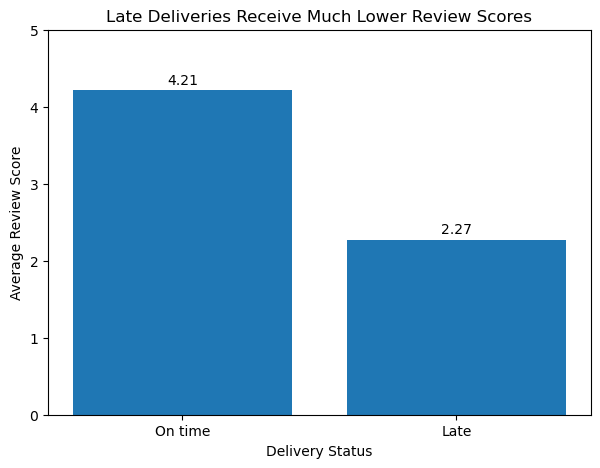

In [182]:
import matplotlib.pyplot as plt

plot_data = review_by_lateness.copy()
plot_data["delivery_status"] = plot_data["is_late"].map({
    False: "On time",
    True: "Late"
})

plt.figure(figsize=(7, 5))

bars = plt.bar(
    plot_data["delivery_status"],
    plot_data["average_review_score"]
)

plt.title("Late Deliveries Receive Much Lower Review Scores")
plt.xlabel("Delivery Status")
plt.ylabel("Average Review Score")
plt.ylim(0, 5)

for bar, value in zip(bars, plot_data["average_review_score"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.08,
        f"{value:.2f}",
        ha="center"
    )

plt.show()

### Interpretation

Late orders received an average review score of 2.27, compared with 4.21 for on-time orders. This is a decline of about 1.94 points on a 5-point scale, showing that delivery reliability is strongly associated with customer satisfaction.

How does handling time affect late-delivery risk?

In [183]:
handling_summary = (
    final_orders.dropna(subset=["handling_days"])
    .assign(
        handling_group=pd.cut(
            final_orders.dropna(subset=["handling_days"])["handling_days"],
            bins=[-0.01, 1, 3, 7, float("inf")],
            labels=["0–1 days", "2–3 days", "4–7 days", "8+ days"]
        )
    )
    .groupby("handling_group", observed=False, as_index=False)
    .agg(
        late_rate=("is_late", "mean"),
        order_count=("order_id", "count")
    )
)

handling_summary["late_rate_pct"] = handling_summary["late_rate"] * 100

handling_summary

,handling_group,late_rate,order_count,late_rate_pct
0,0–1 days,0.045957,51200,4.595703
1,2–3 days,0.062329,24531,6.232930
2,4–7 days,0.090552,15527,9.055194
3,8+ days,0.243087,5027,24.308733


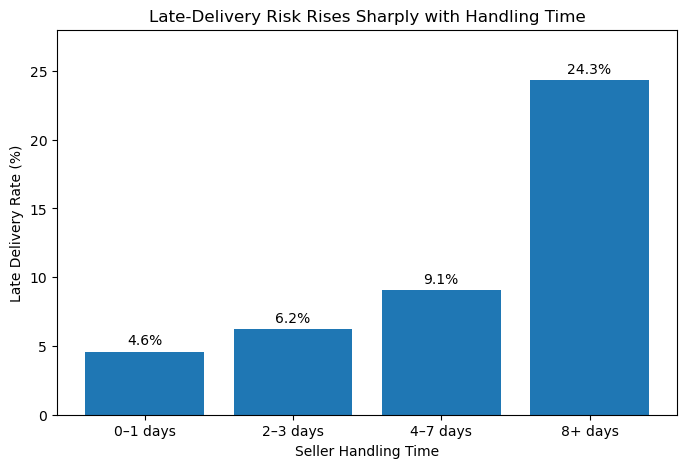

In [184]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    handling_summary["handling_group"].astype(str),
    handling_summary["late_rate_pct"]
)

plt.title("Late-Delivery Risk Rises Sharply with Handling Time")
plt.xlabel("Seller Handling Time")
plt.ylabel("Late Delivery Rate (%)")
plt.ylim(0, 28)

for bar, value in zip(bars, handling_summary["late_rate_pct"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.5,
        f"{value:.1f}%",
        ha="center"
    )

plt.show()

### Interpretation

Late-delivery risk increased steadily as seller handling time grew. Orders handled within one day had a 4.6% late rate, compared with 24.3% for orders taking eight or more days to reach the carrier. This makes long seller handling time a strong operational warning signal and a practical area for intervention.

In [185]:
distance_summary = (
    final_orders.dropna(subset=["max_distance_km"])
    .assign(
        distance_group=pd.cut(
            final_orders.dropna(subset=["max_distance_km"])["max_distance_km"],
            bins=[-0.01, 250, 500, 1000, float("inf")],
            labels=["0–250 km", "251–500 km", "501–1000 km", "1000+ km"]
        )
    )
    .groupby("distance_group", observed=False, as_index=False)
    .agg(
        late_rate=("is_late", "mean"),
        order_count=("order_id", "count")
    )
)

distance_summary["late_rate_pct"] = distance_summary["late_rate"] * 100

distance_summary

,distance_group,late_rate,order_count,late_rate_pct
0,0–250 km,0.045152,27773,4.515177
1,251–500 km,0.063711,28237,6.371073
2,501–1000 km,0.069380,26362,6.938017
3,1000+ km,0.101803,15805,10.180323


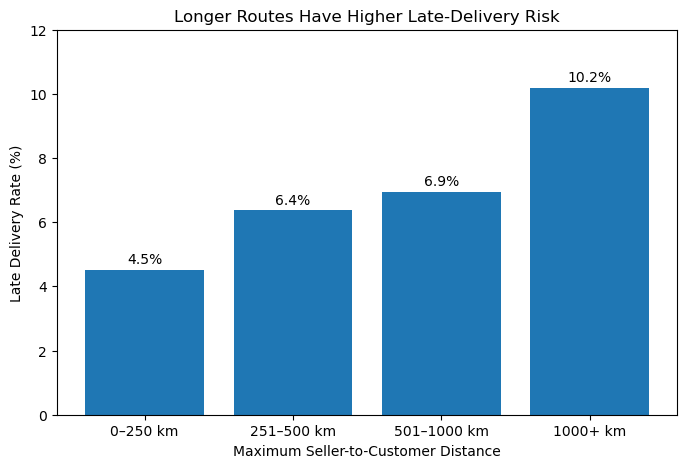

In [186]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    distance_summary["distance_group"].astype(str),
    distance_summary["late_rate_pct"]
)

plt.title("Longer Routes Have Higher Late-Delivery Risk")
plt.xlabel("Maximum Seller-to-Customer Distance")
plt.ylabel("Late Delivery Rate (%)")
plt.ylim(0, 12)

for bar, value in zip(bars, distance_summary["late_rate_pct"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.2,
        f"{value:.1f}%",
        ha="center"
    )

plt.show()

### Interpretation

Late-delivery risk increased with shipping distance. Orders traveling up to 250 km had a 4.5% late rate, while orders traveling more than 1,000 km had a 10.2% late rate. Longer routes therefore appear to create additional fulfillment risk, although distance is less actionable than seller handling time.

What drives frieght cost?

In [187]:
weight_summary = (
    final_orders.dropna(
        subset=["total_weight_g", "total_freight_value"]
    )
    .assign(
        weight_group=pd.cut(
            final_orders.dropna(
                subset=["total_weight_g", "total_freight_value"]
            )["total_weight_g"],
            bins=[-0.01, 500, 2000, 10000, float("inf")],
            labels=["0–0.5 kg", "0.5–2 kg", "2–10 kg", "10+ kg"]
        )
    )
    .groupby("weight_group", observed=False, as_index=False)
    .agg(
        median_freight_value=("total_freight_value", "median"),
        order_count=("order_id", "count")
    )
)

weight_summary

,weight_group,median_freight_value,order_count
0,0–0.5 kg,15.100,39728
1,0.5–2 kg,17.260,34018
2,2–10 kg,23.760,19506
3,10+ kg,49.975,5414


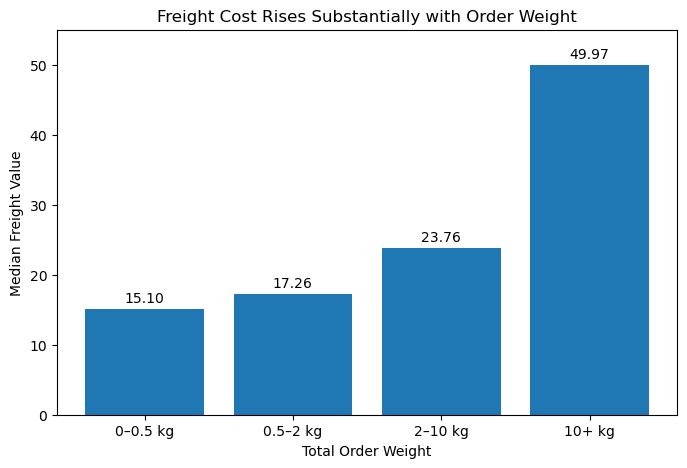

In [188]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    weight_summary["weight_group"].astype(str),
    weight_summary["median_freight_value"]
)

plt.title("Freight Cost Rises Substantially with Order Weight")
plt.xlabel("Total Order Weight")
plt.ylabel("Median Freight Value")
plt.ylim(0, 55)

for bar, value in zip(
    bars,
    weight_summary["median_freight_value"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}",
        ha="center"
    )

plt.show()

### Interpretation

Median freight value increased with total order weight. Orders weighing up to 0.5 kg had a median freight value of 15.10, while orders above 10 kg had a median freight value of 49.98—more than three times as high. This supports the earlier correlation analysis showing that weight is one of the strongest freight-cost drivers.

In [189]:
category_plot = category_summary.copy()

category_plot["estimated_late_orders"] = (
    category_plot["order_count"] * category_plot["late_rate"]
)

category_plot = (
    category_plot.sort_values(
        "estimated_late_orders",
        ascending=False
    )
    .head(10)
)

category_plot[
    [
        "product_category_name_english",
        "order_count",
        "late_rate",
        "estimated_late_orders"
    ]
]

,product_category_name_english,order_count,late_rate,estimated_late_orders
6,bed_bath_table,9417,0.073166,689.0
30,health_beauty,8836,0.073563,650.0
46,sports_leisure,7720,0.064119,495.0
27,furniture_decor,6449,0.069623,449.0
11,computers_accessories,6689,0.062341,417.0
50,watches_gifts,5624,0.072191,406.0
35,housewares,5884,0.052345,308.0
48,telephony,4199,0.069302,291.0
4,auto,3897,0.071337,278.0
49,toys,3886,0.062532,243.0


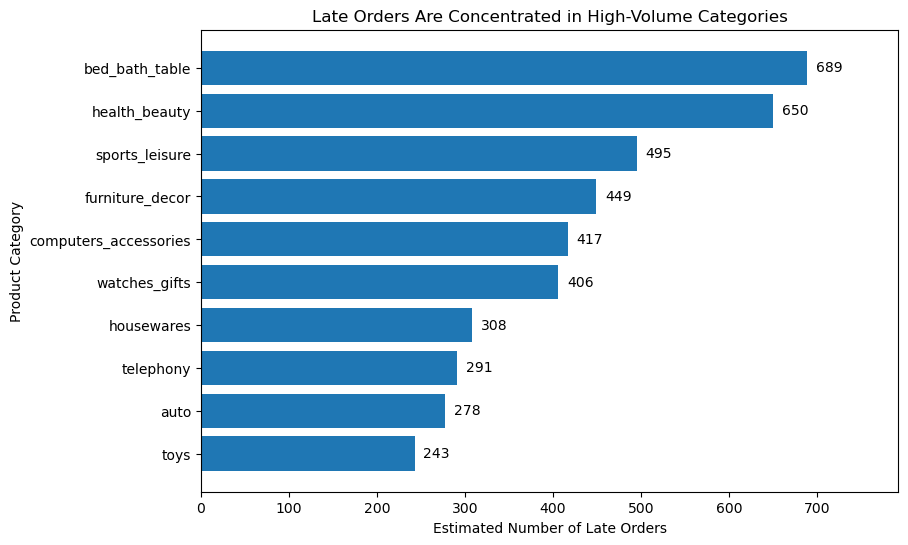

In [190]:
category_plot = category_plot.sort_values(
    "estimated_late_orders",
    ascending=True
)

plt.figure(figsize=(9, 6))

bars = plt.barh(
    category_plot["product_category_name_english"],
    category_plot["estimated_late_orders"]
)

plt.title("Late Orders Are Concentrated in High-Volume Categories")
plt.xlabel("Estimated Number of Late Orders")
plt.ylabel("Product Category")

for bar, value in zip(
    bars,
    category_plot["estimated_late_orders"]
):
    plt.text(
        value + 10,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.0f}",
        va="center"
    )

plt.xlim(
    0,
    category_plot["estimated_late_orders"].max() * 1.15
)

plt.show()

### Interpretation

The largest number of late orders was concentrated in high-volume categories. Bed, bath, and table accounted for about 689 late orders, followed by health and beauty with about 650. These categories are important intervention targets because even moderate late rates affect a large number of customers.

In [191]:
seller_plot = (
    seller_performance[
        seller_performance["order_count"] >= 30
    ]
    .copy()
)

seller_plot["estimated_late_orders"] = (
    seller_plot["order_count"] * seller_plot["late_rate"]
)

seller_plot = (
    seller_plot.sort_values(
        "estimated_late_orders",
        ascending=False
    )
    .head(10)
)

seller_plot[
    [
        "seller_id",
        "order_count",
        "late_rate",
        "median_handling_days",
        "estimated_late_orders"
    ]
]

,seller_id,order_count,late_rate,median_handling_days,estimated_late_orders
881,4a3ca9315b744ce9f8e9374361493884,1806,0.095238,1.0,172.0
368,1f50f920176fa81dab994f9023523100,1404,0.088319,3.0,124.0
857,4869f7a5dfa277a7dca6462dcf3b52b2,1132,0.104240,1.0,118.0
1235,6560211a19b47992c3666cc44a7e94c0,1854,0.051780,0.0,96.0
2836,ea8482cd71df3c1969d7b9473ff13abc,1146,0.083770,2.0,96.0
1535,7c67e1448b00f6e969d365cea6b010ab,982,0.090631,10.0,89.0
2481,cc419e0650a3c5ba77189a1882b7556a,1706,0.050996,1.0,87.0
2643,da8622b14eb17ae2831f4ac5b9dab84a,1314,0.066210,1.0,87.0
1708,8b321bb669392f5163d04c59e235e066,943,0.085896,1.0,81.0
1824,955fee9216a65b617aa5c0531780ce60,1287,0.059829,1.0,77.0


Which sellers create the largest late-delivery impact after considering both risk and scale? the sellers with the most late orders are not always the sellers with the highest late-rate percentage.

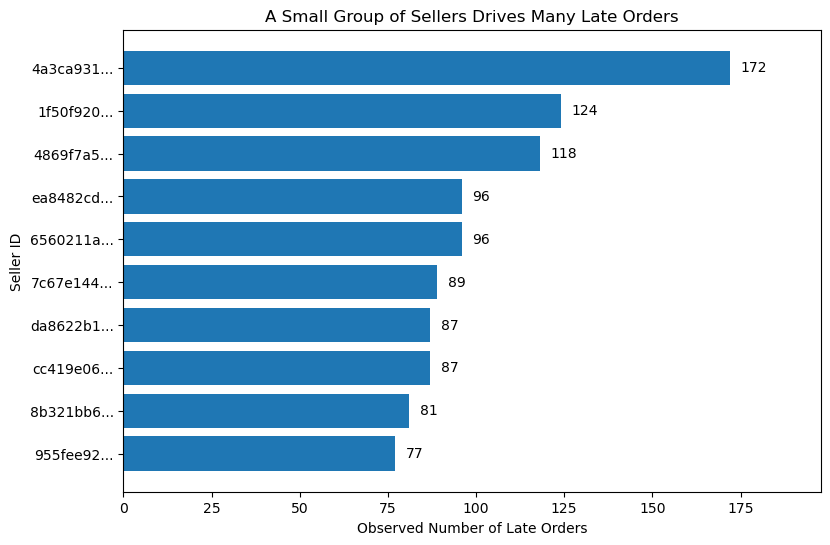

In [192]:
seller_plot = seller_plot.sort_values(
    "estimated_late_orders",
    ascending=True
)

seller_plot["seller_label"] = (
    seller_plot["seller_id"].str[:8] + "..."
)

plt.figure(figsize=(9, 6))

bars = plt.barh(
    seller_plot["seller_label"],
    seller_plot["estimated_late_orders"]
)

plt.title("A Small Group of Sellers Drives Many Late Orders")
plt.xlabel("Observed Number of Late Orders")
plt.ylabel("Seller ID")

for bar, value in zip(
    bars,
    seller_plot["estimated_late_orders"]
):
    plt.text(
        value + 3,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.0f}",
        va="center"
    )

plt.xlim(
    0,
    seller_plot["estimated_late_orders"].max() * 1.15
)

plt.show()

### Interpretation

Late orders were concentrated among a relatively small group of high-volume sellers. The highest-impact seller accounted for about 172 late orders, while several others contributed more than 80 each. Seller monitoring should therefore consider both late-rate severity and total order volume rather than relying on percentage alone.

In [193]:
seller_plot = seller_plot.rename(
    columns={"estimated_late_orders": "late_order_count"}
)